In [14]:
# ==========================================
# IMPORTAR LIBRERÍAS
# ==========================================

# Librería para análisis de datos
import pandas as pd

# Librería para operaciones numéricas
import numpy as np

# Librería para gráficas
import matplotlib.pyplot as plt

# Librería para visualizaciones avanzadas
import seaborn as sns

In [15]:
# ==========================================
# CARGAR DATASET LIMPIO
# ==========================================

# Ruta del dataset limpio
ruta = "../data/processed/energy_dataset_clean.csv"

# Leer dataset limpio
df = pd.read_csv(
    ruta,
    
    # Convertir datetime automáticamente
    parse_dates=["Datetime"]
)

# Mostrar primeras filas
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Datetime,Year,Month,Day,Hour,Weekday
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0.0,1.0,17.0,2006-12-16 17:24:00,2006,12,16,17,Saturday
1,16/12/2006,17:25:00,5.360,0.436,233.63,23.0,0.0,1.0,16.0,2006-12-16 17:25:00,2006,12,16,17,Saturday
2,16/12/2006,17:26:00,5.374,0.498,233.29,23.0,0.0,2.0,17.0,2006-12-16 17:26:00,2006,12,16,17,Saturday
3,16/12/2006,17:27:00,5.388,0.502,233.74,23.0,0.0,1.0,17.0,2006-12-16 17:27:00,2006,12,16,17,Saturday
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0.0,1.0,17.0,2006-12-16 17:28:00,2006,12,16,17,Saturday


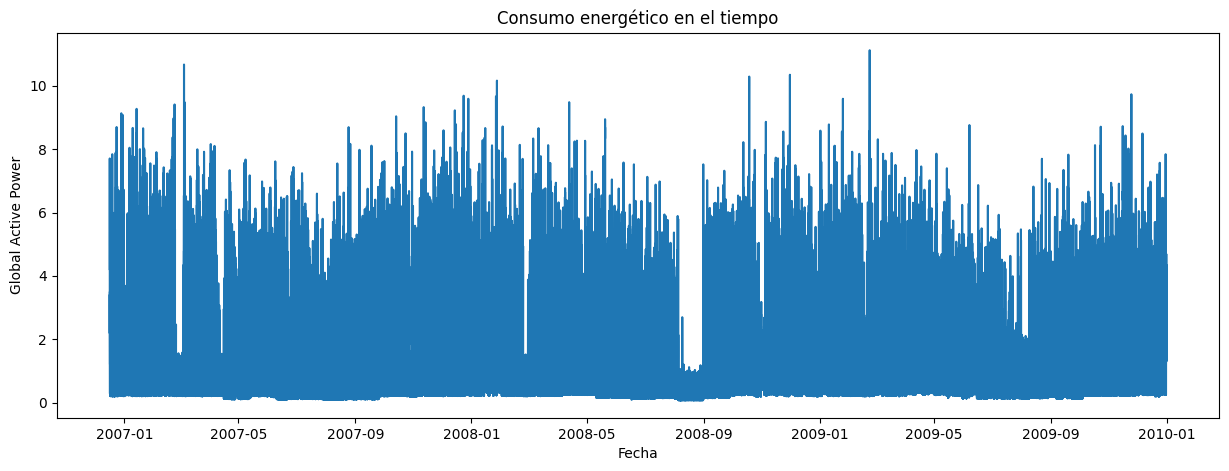

In [16]:
# ==========================================
# CONSUMO ENERGÉTICO EN EL TIEMPO
# ==========================================

# Crear tamaño de la figura
plt.figure(figsize=(15,5))

# Graficar consumo energético
plt.plot(
    
    # Eje X → tiempo
    df["Datetime"],
    
    # Eje Y → consumo energético
    df["Global_active_power"]
)

# Título de la gráfica
plt.title("Consumo energético en el tiempo")

# Nombre eje X
plt.xlabel("Fecha")

# Nombre eje Y
plt.ylabel("Global Active Power")

# Mostrar gráfica
plt.show()

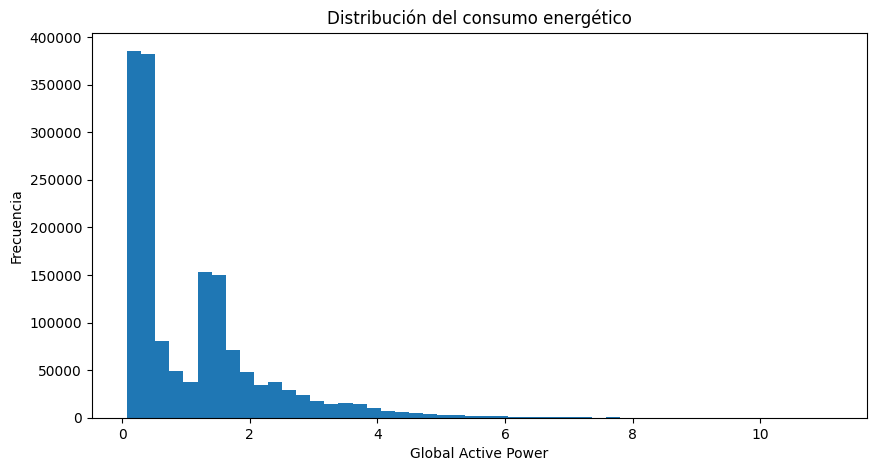

In [17]:
# ==========================================
# HISTOGRAMA DEL CONSUMO ENERGÉTICO
# ==========================================

# Crear tamaño de figura
plt.figure(figsize=(10,5))

# Crear histograma
plt.hist(
    
    # Variable principal
    df["Global_active_power"],
    
    # Número de intervalos
    bins=50
)

# Título de la gráfica
plt.title("Distribución del consumo energético")

# Nombre eje X
plt.xlabel("Global Active Power")

# Nombre eje Y
plt.ylabel("Frecuencia")

# Mostrar gráfica
plt.show()

C:\Users\Andre\AppData\Local\Temp\ipykernel_24196\2576938792.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


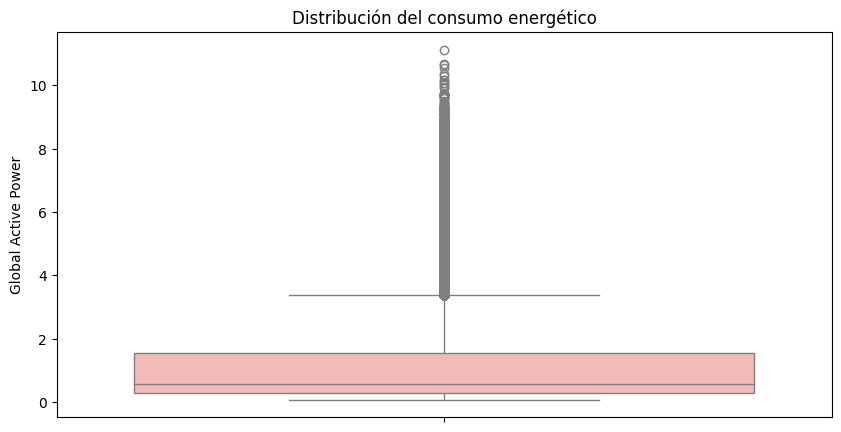

In [18]:

# ==========================================
# BOXPLOT 
# ==========================================

# Crear figura
plt.figure(figsize=(10,5))

# Crear boxplot
sns.boxplot(
    
    # Variable
    y=df["Global_active_power"],
    
    # Paleta de colores
    palette="Pastel1"
)

# Título
plt.title("Distribución del consumo energético")

# Nombre eje Y
plt.ylabel("Global Active Power")

# Mostrar gráfica
plt.show()

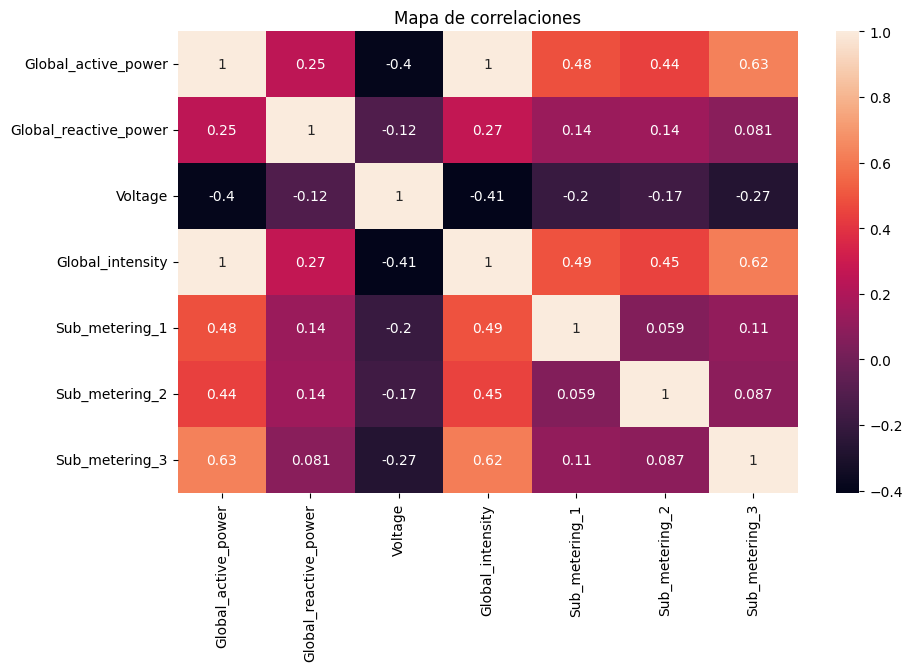

In [19]:
# ==========================================
# HEATMAP DE CORRELACIONES
# ==========================================

# Seleccionar columnas numéricas
correlacion = df[
    [
        "Global_active_power",
        "Global_reactive_power",
        "Voltage",
        "Global_intensity",
        "Sub_metering_1",
        "Sub_metering_2",
        "Sub_metering_3"
    ]
].corr()

# Crear figura
plt.figure(figsize=(10,6))

# Crear heatmap
sns.heatmap(
    
    # Matriz de correlación
    correlacion,
    
    # Mostrar valores
    annot=True
)

# Título de la gráfica
plt.title("Mapa de correlaciones")

# Mostrar gráfica
plt.show()

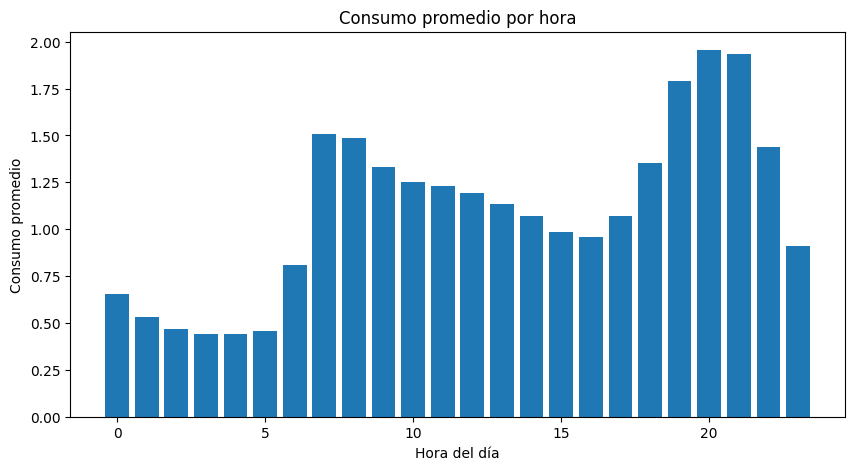

In [20]:
# ==========================================
# CONSUMO PROMEDIO POR HORA
# ==========================================

# Crear columna Hour si no existe
df["Hour"] = df["Datetime"].dt.hour

# Calcular promedio por hora
consumo_hora = df.groupby("Hour")[
    "Global_active_power"
].mean()

# Crear figura
plt.figure(figsize=(10,5))

# Crear gráfico de barras
plt.bar(
    
    # Horas
    consumo_hora.index,
    
    # Promedio consumo
    consumo_hora.values
)

# Título
plt.title("Consumo promedio por hora")

# Eje X
plt.xlabel("Hora del día")

# Eje Y
plt.ylabel("Consumo promedio")

# Mostrar gráfica
plt.show()

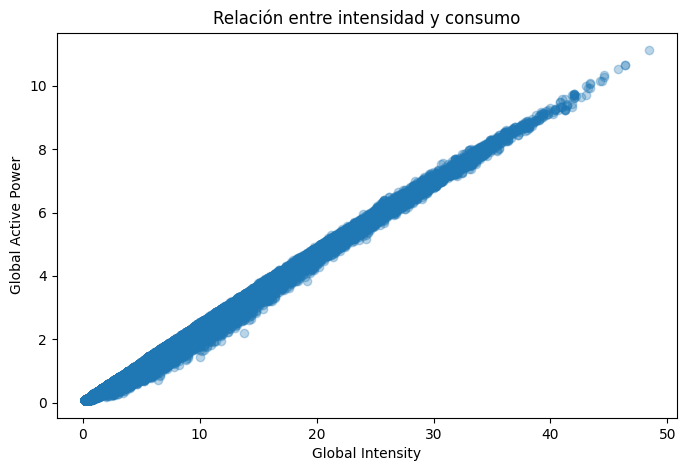

In [21]:
# ==========================================
# DIAGRAMA DE DISPERSIÓN
# ==========================================

# Crear figura
plt.figure(figsize=(8,5))

# Crear scatter plot
plt.scatter(
    
    # Variable X
    df["Global_intensity"],
    
    # Variable Y
    df["Global_active_power"],
    
    # Transparencia
    alpha=0.3
)

# Título
plt.title("Relación entre intensidad y consumo")

# Eje X
plt.xlabel("Global Intensity")

# Eje Y
plt.ylabel("Global Active Power")

# Mostrar gráfica
plt.show()

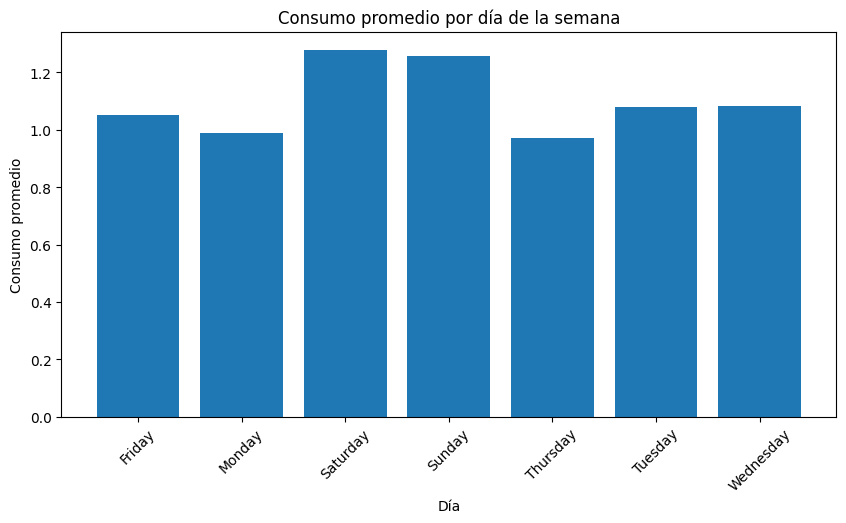

In [22]:
# ==========================================
# CONSUMO PROMEDIO POR DÍA
# ==========================================

# Crear columna Weekday
df["Weekday"] = df["Datetime"].dt.day_name()

# Calcular promedio por día
consumo_dia = df.groupby("Weekday")[
    "Global_active_power"
].mean()

# Crear figura
plt.figure(figsize=(10,5))

# Crear gráfico de barras
plt.bar(
    consumo_dia.index,
    consumo_dia.values
)

# Título
plt.title("Consumo promedio por día de la semana")

# Eje X
plt.xlabel("Día")

# Eje Y
plt.ylabel("Consumo promedio")

# Rotar nombres
plt.xticks(rotation=45)

# Mostrar gráfica
plt.show()